# 01 - Exploratory Data Analysis: Financial PhraseBank

**Phase 1, Task 2** - Dataset exploration for the customer/financial feedback sentiment project.

Dataset: [Malo et al., 2014] Financial PhraseBank, `sentences_allagree` variant — sentences from financial news where all annotators agreed on the sentiment label (Negative / Neutral / Positive).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from src.data.loader import load_raw_dataset

sns.set_theme(style="whitegrid")
FIG_DIR = "../output/figures"

df = load_raw_dataset("../data/raw/financial_phrasebank/all-data.csv")
df.head()

,label,text,label_id
0,neutral,"According to Gran , the company has no plans t...",1
1,neutral,Technopolis plans to develop in stages an area...,1
2,negative,The international electronic industry company ...,0
3,positive,With the new production plant the company woul...,2
4,positive,According to the company 's updated strategy f...,2


## Dataset Shape & Data Quality

In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated text only (different label?): {df.duplicated(subset=['text']).sum()}")

Shape: 4846 rows x 3 columns

Missing values:
label       0
text        0
label_id    0
dtype: int64

Fully duplicated rows: 6
Duplicated text only (different label?): 8


In [3]:
# Drop exact duplicates for downstream splitting/training
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df)} exact duplicate rows -> {len(df)} remaining")

Dropped 6 exact duplicate rows -> 4840 remaining


## Class Distribution

In [4]:
counts = df["label"].value_counts()
pcts = df["label"].value_counts(normalize=True) * 100
dist_table = pd.DataFrame({"count": counts, "pct": pcts.round(1)})
dist_table

,count,pct
label,,
neutral,2873,59.4
positive,1363,28.2
negative,604,12.5


In [5]:
imbalance_ratio = counts.max() / counts.min()
print(f"Majority class: {counts.idxmax()} ({counts.max()} samples)")
print(f"Minority class: {counts.idxmin()} ({counts.min()} samples)")
print(f"Imbalance ratio (majority:minority): {imbalance_ratio:.2f}:1")

Majority class: neutral (2873 samples)
Minority class: negative (604 samples)
Imbalance ratio (majority:minority): 4.76:1


/tmp/ipykernel_16338/3508503923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", order=order, palette=[colors[l] for l in order], ax=ax)


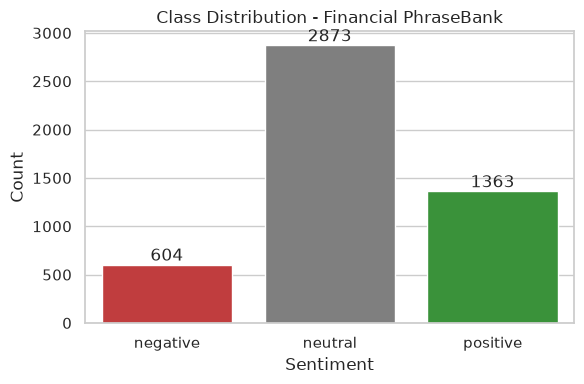

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["negative", "neutral", "positive"]
colors = {"negative": "#d62728", "neutral": "#7f7f7f", "positive": "#2ca02c"}
sns.countplot(data=df, x="label", order=order, palette=[colors[l] for l in order], ax=ax)
ax.set_title("Class Distribution - Financial PhraseBank")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/class_distribution.png", dpi=150)
plt.show()

**Observation:** The dataset is imbalanced — `neutral` dominates (~59%), while `negative` is the minority class (~12%). This mirrors real financial news, where most reported statements are factual/neutral rather than strongly polarized. This imbalance must be handled downstream via stratified splitting, class weighting, and per-class (not just aggregate) evaluation metrics.

## Text Length Statistics

In [7]:
df["n_words"] = df["text"].str.split().str.len()
df["n_chars"] = df["text"].str.len()

print("Word count stats:")
print(df["n_words"].describe())
print("\nChar count stats:")
print(df["n_chars"].describe())

Word count stats:
count    4840.000000
mean       23.092975
std         9.940827
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: n_words, dtype: float64

Char count stats:
count    4840.000000
mean      128.076446
std        56.416479
min         9.000000
25%        84.000000
50%       119.000000
75%       163.000000
max       315.000000
Name: n_chars, dtype: float64


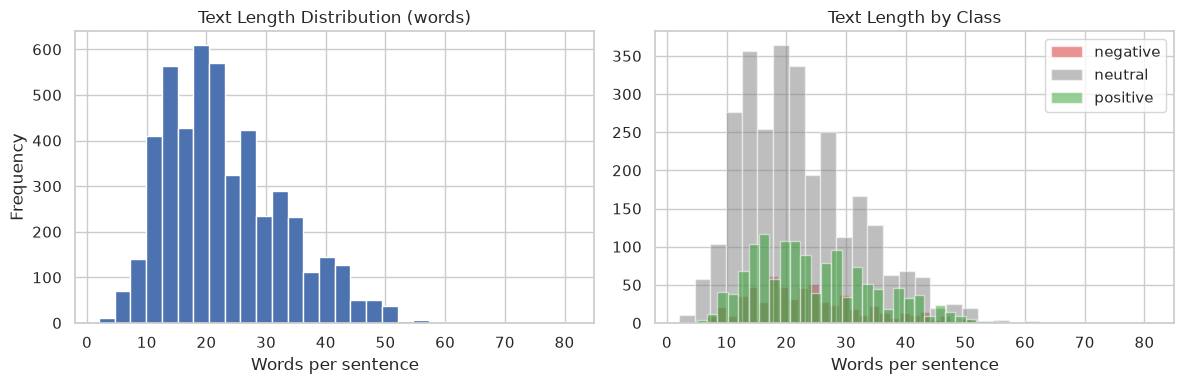

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["n_words"], bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Text Length Distribution (words)")
axes[0].set_xlabel("Words per sentence")
axes[0].set_ylabel("Frequency")

for label in order:
    subset = df[df["label"] == label]["n_words"]
    axes[1].hist(subset, bins=30, alpha=0.5, label=label, color=colors[label])
axes[1].set_title("Text Length by Class")
axes[1].set_xlabel("Words per sentence")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/text_length_distribution.png", dpi=150)
plt.show()

## Sample Texts per Class

In [9]:
for label in order:
    print(f"=== {label.upper()} ===")
    for text in df[df["label"] == label]["text"].sample(3, random_state=42):
        print(f"  - {text}")
    print()

=== NEGATIVE ===
  - The company decided at the end of 2008 to temporarily shut down its ammonia plant in Billingham and extend the maintenance period at its Ince facility .
  - down to EUR5 .9 m H1 '09 3 August 2009 - Finnish media group Ilkka-Yhtyma Oyj ( HEL : ILK2S ) said today its net profit fell 45 % on the year to EUR5 .9 m in the first half of 2009 .
  - The steelmaker said that the drop in profit was explained by the continuing economic uncertainty , mixed with the current drought in bank lending , resulting in a decline in demand for its products as customers find it increasingly difficult to fund operations .

=== NEUTRAL ===
  - The total donation amount is EUR 1,115,000 .
  - Upon establishment , the plan is directed to approximately 20 persons .
  - The company 's share is quoted on NASDAQ OMX Helsinki Rautaruukki Oyj : RTRKS .

=== POSITIVE ===
  - The new agreement , which expands a long-established cooperation between the companies , involves the transfer of certain en

## Word Clouds by Class

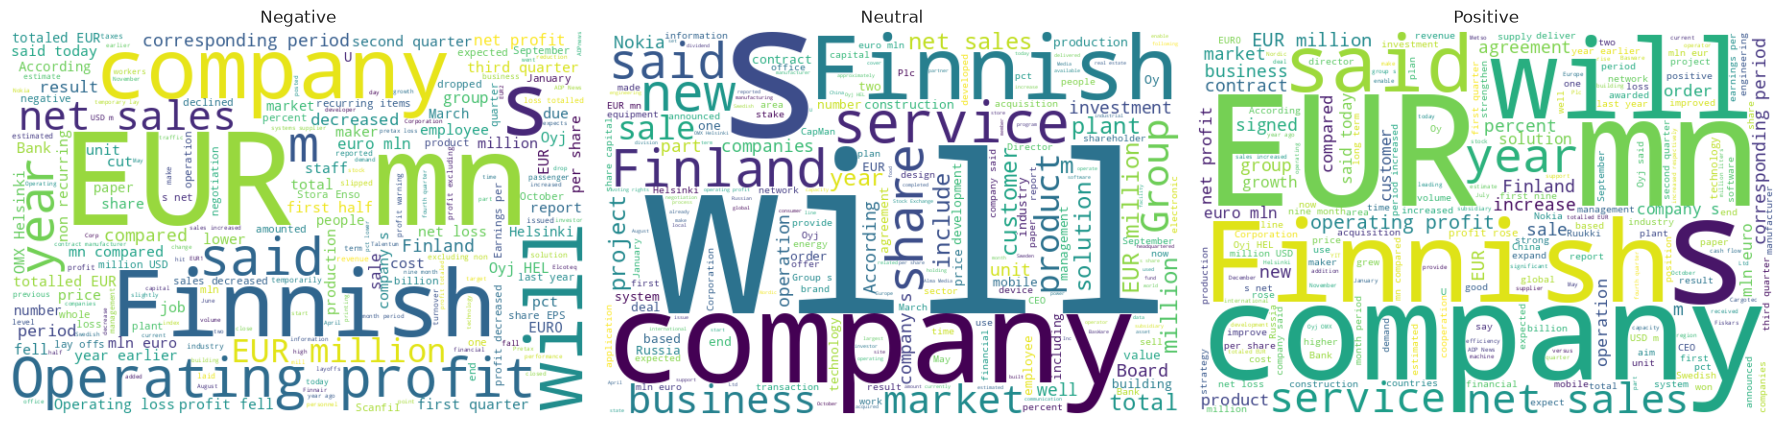

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, label in zip(axes, order):
    text_blob = " ".join(df[df["label"] == label]["text"])
    wc = WordCloud(width=600, height=400, background_color="white", colormap="viridis").generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label.capitalize())
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/wordclouds_by_class.png", dpi=150)
plt.show()

## Findings Summary

1. **Size:** 4,840 unique sentences after de-duplication (6 exact duplicates removed from the raw 4,846).
2. **Class imbalance:** `neutral` ~59%, `positive` ~28%, `negative` ~12% — roughly a 4.8:1 ratio between majority and minority class. Requires stratified splits and weighted/per-class metrics (not raw accuracy).
3. **No missing values.**
4. **Text length:** short sentences overall (median ~21 words), max 81 words. A `max_length=128` token budget for the RoBERTa tokenizer comfortably covers the full corpus (verified separately in Task 3 — 100% of samples fit under 128 tokens).
5. **Content:** sentences are formal financial-news style statements (revenue, profit, sales figures), consistent with the source (Finnish public company press releases circa 2014).
6. **Vocabulary by class:** positive/negative word clouds are dominated by directional financial terms (increase/decrease, profit/loss), while neutral sentences skew toward descriptive/procedural language (plans, agreements, dates).